In [1]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import scipy.integrate

# <b> Core Task 1 </b>: Octuple integral

### Calculate value of integral

In [2]:
def mc_vectorized(N):
    """
    Function calculating the value of the octuple integral using vectorised Monte Carlo
    N = number of sampling points taken within the volume of integration in N-dimensional space
    Returns tuple of (estimate, error) for the integral
    """
    a = 0
    b = pi/8
    V = (pi/8)**8 # 8D volume of integration range
    x = np.random.rand(8, N) * (b-a) # Initiate coordinate grid, N samples of 8D vectors; x.size = (8, N)
    
    sines = 10**6 * np.sin(x.sum(axis=0)) # At each of the N points, sum over values of all coords and take sine. sines.size = (N,)
    ef = sines.sum()/N # expectation value <f> using eq (5)
    ef2 = (sines**2).sum()/N # expectation value <f**2> using eq (6)

    estimate = V * ef  # eq (3)
    sigma = V * ((ef2 - ef**2)/N)**(0.5) # eq (5)
    
    return (estimate, sigma)

In [3]:
mc_vectorized(10**7)

(537.1727832252086, 0.011949538684961129)

The value of the integral was calculated to be 537.170±0.012, within 2σ of the analytical value 537.187.
This was obtained from using the largest possible N (10**7) without exceeding the memory capacity of the computer, which was the limiting factor for the vectorized function rather than computing time.

### Plot scaling of error with sample size N

In [4]:
# Calculate error from standard deviation of estimate from 25 independent estimates
def mc_error(N):
    """Returns estimated (experimental error, theoretical error) from 25 trials of calculating 
    the integral using N points"""
    nt = 25 # number of trials
    data = np.zeros(nt)
    sigmas = np.zeros(nt) 
    for i in range(nt):
        data[i], sigmas[i] = mc_vectorized(N)
    #print(data.mean())
    return data.std(), sigmas.mean() # experimental scatter, theoretical error

exp_errors = np.zeros(6) # experimental errors from standard deviation
the_errors = np.zeros(6) # theoretical prediction of error, proportional to N^(-1/2) from eq (5)
for i in range(0, 6):
    exp_errors[i], the_errors[i] = mc_error(10**(i+1))

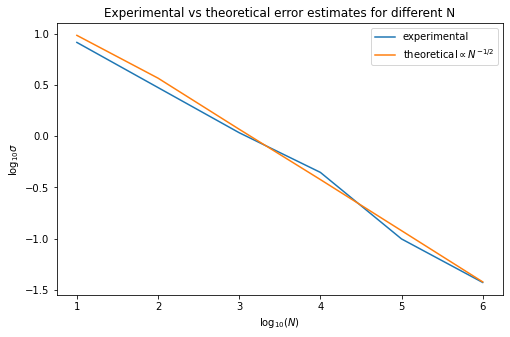

In [5]:
# Plot experimental vs experimental error
Nvals = np.arange(1,7,1)
plt.figure(figsize=(8,5))
plt.plot(Nvals, np.log10(exp_errors), label="experimental")
plt.plot(Nvals, np.log10(the_errors), label="theoretical$\propto N^{-1/2}$")
plt.title("Experimental vs theoretical error estimates for different N")
plt.xlabel("$\log_{10}(N)$")
plt.ylabel("$\log_{10}\sigma$")
plt.legend();

The experimental scatter agrees well with the theoretical prediction that the error is proportional to N^-0.5; the two lines sit nearly on top of each other.

# <b> Core Task 2 </b>: Calculating Fresnel integrals

In [6]:
# Defining the Fresnel integrals and vectorize them for speed
def cfunc(x):
    return np.cos(pi*x**2/2)

def sfunc(x):
    return np.sin(pi*x**2/2)

def C(u):
    return scipy.integrate.quad(cfunc, 0, u)[0] # return value of result rather than the error

def S(u):
    return scipy.integrate.quad(sfunc, 0, u)[0]

C = np.vectorize(C)
S = np.vectorize(S)

In [7]:
# Calculate C(u) and S(u) for -20 < u < 20
end = 20
points = 2000
u = np.linspace(-end, end, points)
c = C(u)
s = S(u);

C:\Users\zixia\AppData\Local\Temp/ipykernel_11820/3709287329.py:9: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return scipy.integrate.quad(cfunc, 0, u)[0] # return value of result rather than the error
C:\Users\zixia\AppData\Local\Temp/ipykernel_11820/3709287329.py:12: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  proba

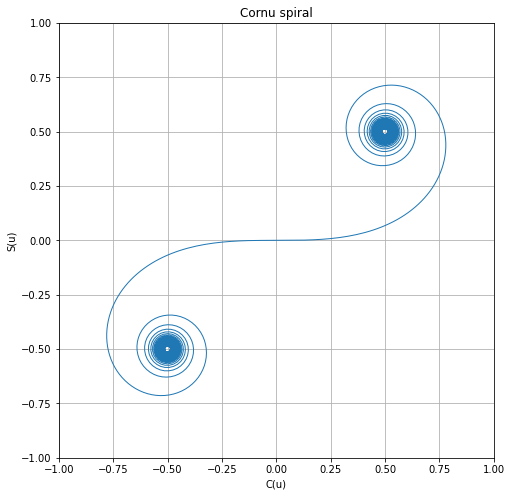

In [8]:
# Plot the spiral
plt.figure(figsize=(8,8))
plt.plot(c, s, lw='1')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.gca().set_aspect("equal")
plt.title("Cornu spiral")
plt.xlabel("C(u)")
plt.ylabel("S(u)")
plt.grid();

# <b> Supplementary Task 1 </b>: Comparing speed of vectorization

In [9]:
def mc_loop1(N):
    """Calculate value of integral and its error, removing one layer of vectorization"""
    a = 0
    b = pi/8
    V = (pi/8)**8 # 8D volume of integration range

    f_sum = f2_sum = 0
    for i in range(N):
        # Loop over N points, adding value of integrand and its square to compute the sums in eq (4) and (5)
        x = np.random.rand(8) * (b-a) # random point in integration volume
        f_x = 10**6*np.sin(x.sum()) # value of integrand at x
        f_sum += f_x # add to sum of f
        f2_sum += f_x**2 # add to sum of squares of f
    ef = f_sum/N # estimated value of f
    ef2 = f2_sum/N # estimated value of f squared

    estimate = V * ef  # eq (3)
    sigma = V * ((ef2 - ef**2)/N)**(0.5) # eq (5)

    return (estimate, sigma)


In [10]:
%timeit mc_vectorized(10**5)

14.8 ms ± 2.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
%timeit mc_loop1(10**5)

889 ms ± 93.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Adding just one layer of vectorization caused a speed improvement of around 50x (from ~500ms to 10ms for N=10**5); clearly preferable here. However, vectorization may not always be optimal - although speed is improved, memory usage is also higher. If memory rather than time is the limiting factor (as was the case in task 1), looped based methods may achieve higher accuracy, since the only memory required is that needed for each step, rather than all of them at once.

In [12]:
%time mc_loop1(5*10**6)

Wall time: 38.8 s


(537.2004229848989, 0.01688795297894809)

The largest value of N that returns a result within a minute is around 5*10**6, which has a larger error than the vectorized limit (0.017 vs 0.012), so if the acceptable time threshold is 1 minute vectorization is optimal.

# <b> Supplementary Task 2 </b>: Period of pendulum

### Calculating the elliptical integral

In [13]:
# Define constants
l = g = 1
T0 = 2*np.pi # Natural oscillation frequency

In [14]:
# Define functions to compute the integral and vectorize for speed
def f_elliptical(theta, theta_m):
    """Defines the elliptical integral as a function of theta and the amplitude theta_m"""
    return np.sqrt(8*l/g) * (np.cos(theta) - np.cos(theta_m))**(-1/2)

def period_int(theta_m):
    """Returns period of pendulum with initial amplitude theta_m by direct computation of the 
    elliptical integral"""
    return scipy.integrate.quad(f_elliptical, 0, theta_m, args=(theta_m,))[0]

def period_int_error(theta_m):
    """Returns error on period from direct integration"""
    return scipy.integrate.quad(f_elliptical, 0, theta_m, args=(theta_m,))[1]

period_int = np.vectorize(period_int)
period_int_error = np.vectorize(period_int_error)

In [15]:
period_int(np.pi/2) # Check it matches the period found using the ODE integrator

array(7.41629871)

In [16]:
# Calulate period for angles in range 0 < theta < pi
N = 100
angles_quad = np.linspace(0, np.pi, N)[1:N-1] # remove zero amplitude and pi
periods_quad = period_int(angles_quad)
periods_quad_error = period_int_error(angles_quad)

### Comparison to results derived from ODE integrator in Exercise 1

In [17]:
# Fetching relevant data from E1, and print the angle at which the ODE integrator fails
def pend_deriv(t, y, q, F):
    y0, y1 = y
    dy0 = y1
    dy1 = -g/l * np.sin(y0) - q*y1 + F*np.sin(2/3*t)
    return [dy0, dy1]

def pend_solution(start, end, dt, amplitude, q=0, F=0):
    solution = scipy.integrate.solve_ivp(
        fun=pend_deriv,
        t_span=(start, end),
        y0=(amplitude, 0),
        t_eval = np.arange(start, end, dt),
        args=(q, F)
    )
    return solution

def period(omega, t):
    return t[1:][omega[1:] * omega[:-1] <= 0][2]

angles_ODE = np.linspace(0, np.pi, 500)[1:] # remove zero amplitude
periods_ODE = [] # list of periods
failed = False

for angle in angles_ODE:
    # Loop through all initial angles, perform integration for each angle, find period and append to a list
    solution = pend_solution(0, 8*T0, dt=0.001, amplitude=angle, q=0, F=0)
    t = solution.t
    omega = solution.y[1]
    # Some solutions are difficult for the integrator (when initial angle is nearly vertical); flag these up
    try:
        angle_period = period(omega, t)
        if not failed:
            periods_ODE.append(angle_period)
    except:
        if failed == False:
            print(f"ODE integrator failed at {angle:.2f} rad")
        failed = True
        

angles_ODE = angles_ODE[:len(periods_ODE)] # remove ill-behaved angles

ODE integrator failed at 3.01 rad


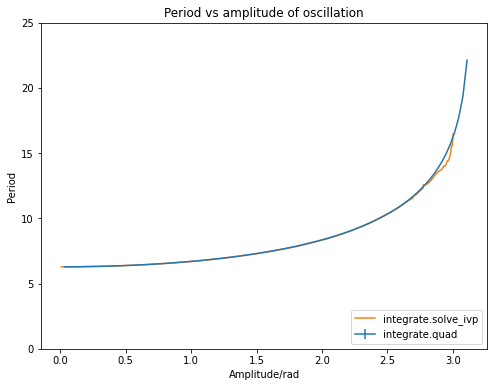

In [18]:
# Plot period vs initial amplitude
plt.figure(figsize=(8,6))
plt.errorbar(angles_quad, periods_quad, yerr=periods_quad_error, label='integrate.quad')
plt.plot(angles_ODE, periods_ODE, label='integrate.solve_ivp')
plt.ylim(0,25)
plt.legend(loc="lower right")
plt.title("Period vs amplitude of oscillation")
plt.xlabel("Amplitude/rad")
plt.ylabel("Period");

In [19]:
periods_quad_error.max()

1.8557124192852825e-07

The two integrators agree up to an initial amplitude of around 2.7 rad. Beyond this, the ODE integrator is no longer smooth, and fails at the points above 3.0 rad (due to innacuracies involving wraparound). The scipy.quad integrator does a much better job at angles close to pi, since the period is found through direct integration instead of inferring it from the time evolution of the angle by finding where the zeroes are.

Error bars were plotted using the errors given by the quad integrator. These were of maximum order 10e-7, which is negligible and cannot be seen on the plot. In comparison, the deviation from the ODE integrator is visible on the graph, with a maximum deviation of around 1 second, which is a much larger error.

Therefore, using the quad integrator directly is definitely far more accurate.